## Auto loan prediction

In [1]:
# load relevant libraries
options(jupyter.plot_mimetypes = c("text/plain", "image/png" ))
library(tidyverse)
library(caret)
library(glmnet)
library(stargazer)
# library(lemon)
library(knitr)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-2


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




## This is a Markdown cell

Yeshhhh

wooo


In [2]:


# knit_print.data.frame <- lemon_print

data_dictionary = read.csv("data/Data_Dictionary.csv")

kable(data_dictionary)



|Variable                   |Description                                                                                                                  |
|:--------------------------|:----------------------------------------------------------------------------------------------------------------------------|
|ID                         |Client Loan application ID                                                                                                   |
|Client_Income              |Client Income in $                                                                                                           |
|Car_Owned                  |Any Car owned by client before applying for the loan for another car (0 means No and 1 means otherwise)                      |
|Bike_Owned                 |Any bike owned by client (0 means No and 1 means otherwise)                                                                  |
|Active_Loan                |Any other active loan at the time

In [19]:
data = read.csv("data/train_dataset.csv")

# str(data)

# Convert the following to numeric
to_num = c('Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 
           'Registration_Days', 'ID_Days', 'Mobile_Tag', 'Score_Source_3') 

data[, to_num] = lapply(data[, to_num],as.numeric)

# Client_Occupation set blank to None, leave NA


to_factor = c('Application_Process_Hour', 'Application_Process_Day', 'Accompany_Client', 'Client_Income_Type',
             'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 
              'Client_Housing_Type','Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 
              'Type_Organization')

data[, to_factor] = lapply(data[, to_factor],as.factor)

str(data)

#Own house age to 0, Own_House will indicate if missing.

Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”


'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity              : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client          : Factor w/ 8 levels "","##","Alone",..: 3 3 3 3 3 3 3 3 8 3 ...
 $ Client_Income_Type        : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education          : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...
 $ Client_Marital_Status     : Factor

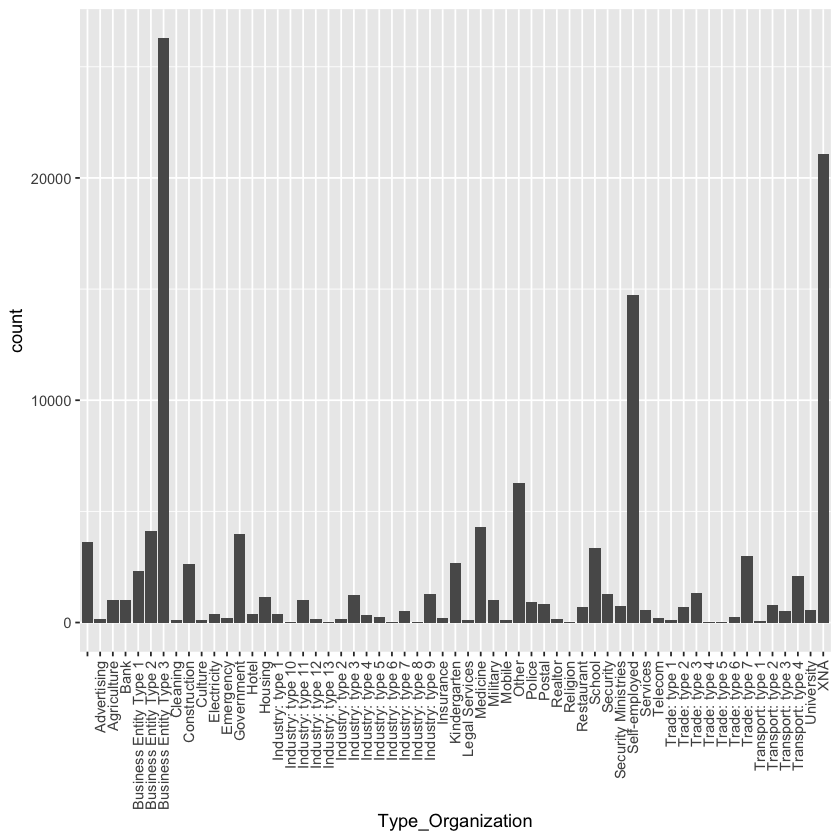

In [20]:
# Distribution of the 59 levels of the Type_Organization factor
ggplot(data) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))


In [21]:
# Perform LASSO to identify categories to merge for Type Organization 

x_train <- model.matrix( ~ Type_Organization, data = data)
lasso_type_org = glmnet(x_train, data$Default, family = "binomial", alpha=1)


print(coef(lasso_type_org)[,20][which(abs(coef(lasso_type_org)[,20]) > 0.1)])


                         (Intercept)         Type_OrganizationAgriculture 
                          -2.4326990                            0.1687661 
               Type_OrganizationBank        Type_OrganizationConstruction 
                          -0.1098251                            0.3364007 
          Type_OrganizationInsurance              Type_OrganizationPolice 
                          -0.1514028                           -0.2290746 
             Type_OrganizationSchool            Type_OrganizationSecurity 
                          -0.2566446                            0.1275355 
Type_OrganizationSecurity Ministries       Type_OrganizationSelf-employed 
                          -0.1755129                            0.1933645 
  Type_OrganizationTransport: type 3                 Type_OrganizationXNA 
                           0.4115849                           -0.3215006 


In [22]:
# Type_Organization variables with largest non-zero coefficients

vars_to_keep = c('XNA'
,'Bank'
,'Insurance'
,'School'
,'Security Ministries'
,'Transport: type 3'
,'Agriculture'
,'Construction'
,'Police'
,'Security'
,'Self-employed')

data = data %>%
    mutate(Type_Organization = case_when(as.character(Type_Organization) %in% vars_to_keep ~ as.character(Type_Organization), TRUE ~ "Other") %>% as.factor())


# set reference level to "Other"
data[, 'Type_Organization'] = relevel(data[, 'Type_Organization'], ref = 'Other')
levels(data[, 'Type_Organization'])

[1] "Other"               "Agriculture"         "Bank"               
 [4] "Construction"        "Insurance"           "Police"             
 [7] "School"              "Security"            "Security Ministries"
[10] "Self-employed"       "Transport: type 3"   "XNA"

In [23]:
x_train <- model.matrix( ~ Client_Occupation, data = data)
lasso_client_occ = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# lasso_client_occ
print(coef(lasso_client_occ)[,20][which(abs(coef(lasso_client_occ)[,20]) > 0.1)])

                        (Intercept)        Client_OccupationAccountants 
                         -2.5757229                          -0.1022047 
          Client_OccupationCleaning            Client_OccupationCooking 
                          0.1137728                           0.3599217 
           Client_OccupationDrivers           Client_OccupationLaborers 
                          0.4119356                           0.3843504 
Client_OccupationLow-skill Laborers              Client_OccupationSales 
                          0.8294368                           0.2870227 
          Client_OccupationSecurity 
                          0.3847612 


In [24]:
# Client_Occupation variables with largeset non-zero coefficient

vars_to_keep = c('Drivers', 'Low-skill Laborers', 'Security', 'Sales', 'Laborers', 'Cooking', 
                 'Cleaning', 'Accountants') 

# re-factor Client_Occupation
data = data %>%
    mutate(Client_Occupation = case_when(as.character(Client_Occupation) %in% vars_to_keep ~ as.character(Client_Occupation), TRUE ~ "Other") %>% as.factor())

# check to make sure there are 9 levels
# str(data[, 'Client_Occupation'])

# set reference level to "Other"
data[, 'Client_Occupation'] = relevel(data[, 'Client_Occupation'], ref = 'Other')
levels(data[, 'Client_Occupation'])

[1] "Other"              "Accountants"        "Cleaning"          
[4] "Cooking"            "Drivers"            "Laborers"          
[7] "Low-skill Laborers" "Sales"              "Security"

In [25]:
# Perform LASSO to identify categories to merge for Application_Process_Hour
x_train <- model.matrix( ~ Application_Process_Hour, data = data)
lasso_app_hour = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# print(coef(lasso_app_hour)[,20][which(abs(coef(lasso_app_hour)[,20]) > 0.1)])


In [26]:
# set values from our LASSO regression
vars_to_keep = c('1', '19', '6', '0', '17', '5', '7') 

# re-factor Application_Process_Hour
data = data %>%
    mutate(Application_Process_Hour = case_when(as.character(Application_Process_Hour) %in% vars_to_keep ~ as.character(Application_Process_Hour), TRUE ~ "Other") %>% as.factor())

# set reference level to "Other"
data[, 'Application_Process_Hour'] = relevel(data[, 'Application_Process_Hour'], ref = 'Other')


In [27]:
# check for columns with missing values
cols_with_missing = which(colSums(is.na(data)) > 0 )
print(cols_with_missing)
print(colSums(is.na(data)) )

# create dummy flags for columns with missing data
missing_data = ifelse(is.na(data[,cols_with_missing]),1,0)

# change column names
colnames(missing_data)<-paste(colnames(missing_data),"na",sep="_")

# append to data frame
data = cbind(data, missing_data)

# check to make sure we added correctly
summary(data$Default)


             Client_Income                  Car_Owned 
                         2                          3 
                Bike_Owned                Active_Loan 
                         4                          5 
                 House_Own                Child_Count 
                         6                          7 
             Credit_Amount               Loan_Annuity 
                         8                          9 
Population_Region_Relative                   Age_Days 
                        17                         18 
             Employed_Days          Registration_Days 
                        19                         20 
                   ID_Days              Own_House_Age 
                        21                         22 
     Client_Family_Members         Cleint_City_Rating 
                        27                         28 
   Application_Process_Day             Score_Source_1 
                        29                         34 
          

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.08079 0.00000 1.00000 

In [28]:
# fix some values in the Accompany_Client data
vals_to_fix = c("", "##",  NA_character_, "0")
data = data %>% 
    mutate(Accompany_Client = case_when(as.character(Accompany_Client) %in% vals_to_fix ~ "Nothing", TRUE ~ as.character(Accompany_Client)) %>% as.factor(),
          Application_Process_Day = case_when(as.character(Application_Process_Day) %in% vals_to_fix ~ "0", TRUE ~ as.character(Application_Process_Day)) %>% as.factor())

# set reference level to "Nothing" or "0" 
data[, 'Accompany_Client'] = relevel(data[, 'Accompany_Client'], ref = 'Nothing')
data[, 'Application_Process_Day'] = relevel(data[, 'Application_Process_Day'], ref = '0')

# remove these non-numeric columns
drop = c('Accompany_Client', 'Application_Process_Day')
cols_with_missing = cols_with_missing[!(names(cols_with_missing) %in% drop)]

# replace missing values in non-numeric columns
data[,cols_with_missing] = data[,cols_with_missing] %>% mutate_all(~replace_na(.,0))

str(data)

'data.frame':	121856 obs. of  63 variables:
 $ ID                           : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income                : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                    : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                   : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan                  : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                    : int  0 0 0 1 0 1 1 1 1 1 ...
 $ Child_Count                  : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount                : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity                 : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client             : Factor w/ 7 levels "Nothing","Alone",..: 2 2 2 2 2 2 2 2 7 2 ...
 $ Client_Income_Type           : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education             : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...


In [29]:
# Ensure there is no more missing data 
print(which(colSums(is.na(data)) > 0 )) 

named integer(0)


In [30]:
# convert default to factor
data = data %>% mutate(Default = case_when(Default == 0 ~ "No", TRUE ~ "Yes")) 
data$Default = factor(data$Default, levels = c("No", "Yes"))

#fix spaces in factors levels that have them to run properly in caret random forest
# data = data %>% 
#   mutate(Client_Income_Type = factor(Client_Income_Type, labels = make.names(levels(Client_Income_Type))), 
#         Client_Education = factor(Client_Education, labels = make.names(levels(Client_Education))), 
#         Client_Marital_Status = factor(Client_Marital_Status, labels = make.names(levels(Client_Marital_Status))), 
#         Client_Gender = factor(Client_Gender, labels = make.names(levels(Client_Gender))), 
#         Loan_Contract_Type = factor(Loan_Contract_Type, labels = make.names(levels(Loan_Contract_Type))), 
#         Client_Housing_Type = factor(Client_Housing_Type, labels = make.names(levels(Client_Housing_Type))),
#         Application_Process_Day = factor(Client_Housing_Type, labels = make.names(levels(Application_Process_Day))))

# drop ID column on training data
training = data[, !(names(data) %in% c("ID"))]

In [31]:
# mtrys<-seq(1,4,1)
# mtrys = floor(sqrt(ncol(training)))
# ntrees = c(500)
# combo_mtrTrees<-data.frame(expand.grid(mtrys, ntrees))
# colnames(combo_mtrTrees)<-c('mtrys','ntrees')

# # mtry=floor(sqrt(ncol(x))) and ntree=500

# tuneGrid <- expand.grid(.mtry = c(mtrys))

# for (i in 1:length(ntrees)){
#   ntree<-ntrees[i]
#   set.seed(1990)
#   rf_maxtrees <- train(Default~.,
#                        data = training,
#                        method = "rf",
#                        importance=TRUE,
#                        metric = "Accuracy",
#                        tuneGrid = tuneGrid,
#                        trControl = trainControl( method = "oob",
#                                                  search = "grid",
#                                                  classProbs = TRUE,
#                                                  savePredictions = "final") ) 
#     }

In [32]:
# print(rf_maxtrees$results)

# control = trainControl(method="cv", number=5, search="random")
# mtry = sqrt(ncol(training))
# rf_random = train(Default~., data=training, method="rf", metric="Accuracy", tuneLength=10, trControl=control)


In [33]:
# logistic regression
test = glm(Default ~ . , data=training, family="binomial")
summary(test)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Default ~ ., family = "binomial", data = training)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.4731  -0.4395  -0.3256  -0.2335   8.4904  

Coefficients:
                                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -1.105e+01  3.247e+02  -0.034 0.972852    
Client_Income                        -3.237e-06  1.531e-06  -2.115 0.034467 *  
Car_Owned                            -6.663e-03  1.403e-01  -0.047 0.962136    
Bike_Owned                           -2.560e-03  2.348e-02  -0.109 0.913172    
Active_Loan                           1.008e-02  2.210e-02   0.456 0.648235    
House_Own                             8.779e-02  2.519e-02   3.485 0.000491 ***
Child_Count                          -2.722e-02  5.153e-02  -0.528 0.597305    
Credit_Amount                        -1.222e-06  4.456e-07  -2.742 0.006114 ** 
Loan_Annuity                          7.187e-05  1.247e-05   5.763 8.28e-09 ***

In [70]:
length(summary(test)$coef[,4])



# print(data.frame(coefs = summary(test)$coef[summary(test)$coef[,4] <= .05, 1]) )


[1] 117

 1  2  3  4  5 
No No No No No 
Levels: No Yes


[1] "No"  "Yes"

[1] "No"  "Yes"

Confusion Matrix and Statistics

          Reference
Prediction    No   Yes
       No  99889  6173
       Yes 12122  3672
                                          
               Accuracy : 0.8499          
                 95% CI : (0.8478, 0.8519)
    No Information Rate : 0.9192          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.2076          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.37298         
            Specificity : 0.89178         
         Pos Pred Value : 0.23249         
         Neg Pred Value : 0.94180         
             Prevalence : 0.08079         
         Detection Rate : 0.03013         
   Detection Prevalence : 0.12961         
      Balanced Accuracy : 0.63238         
                                          
       'Positive' Class : Yes             
                  

Setting levels: control = No, case = Yes

Setting direction: controls < cases



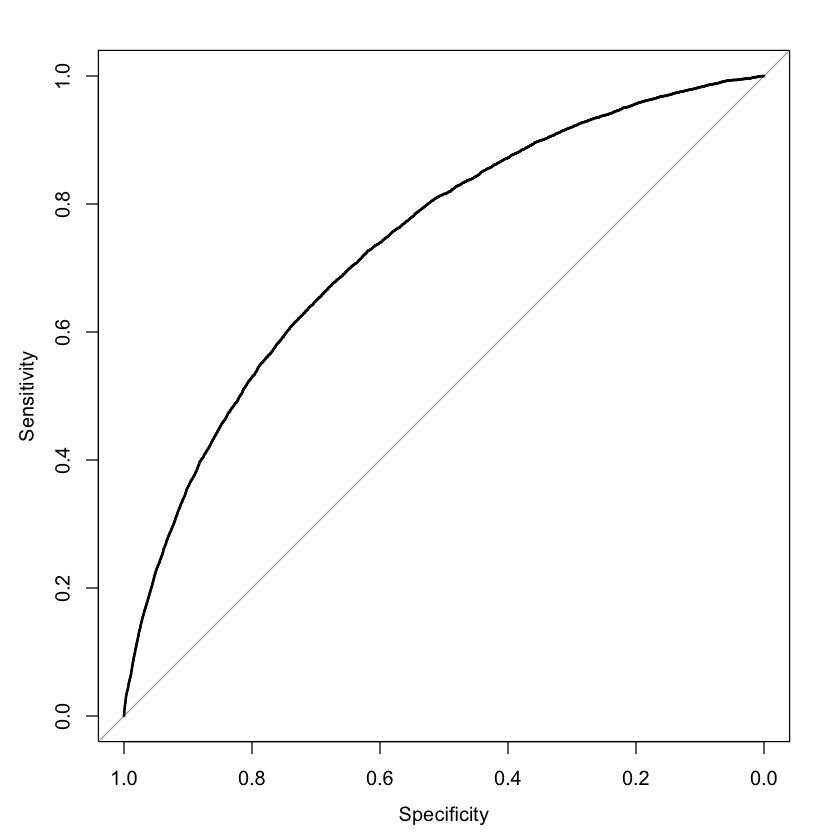

In [56]:
pred = ifelse(predict(test, newdata=training, type="response") < .15, "No", "Yes") %>% as.factor()
print(pred %>% head(5))

levels(pred) = c("No", "Yes")
levels(pred)
levels(training$Default)

caret::confusionMatrix(pred, training$Default, positive="Yes")

library(pROC)

plot.roc(training$Default,
         predict(test, newdata=training, type="response"))

In [ ]:
x_train <- model.matrix(Default ~ ., data = training)
enet = glmnet(x_train, training$Default, family = "binomial", alpha=.5)


In [ ]:
pred = ifelse(predict(enet,newx=x_train, type="response") < .11, "No", "Yes") %>% as.factor()
# print(pred %>% head(5))

caret::confusionMatrix(pred, training$Default, positive="Yes")